# Olist E-Commerce Sales Analysis
**Goal:** Analyze the Brazilian Olist e-commerce dataset to uncover revenue trends, top categories, customer behavior, and delivery performance.

**Steps in this notebook:**
1. Load & merge data
2. Clean data
3. Exploratory analysis (EDA)
4. Business insights
5. Export a cleaned dataset for your BI dashboard (Power BI / Tableau)


## 1. Setup & Load Data


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
cat_translation = pd.read_csv("product_category_name_translation.csv")

print("Orders:", orders.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)

Orders: (99441, 8)
Items: (112650, 7)
Customers: (99441, 5)
Payments: (103886, 5)
Products: (32951, 9)
Reviews: (99224, 7)


## 2. Merge into one master table

In [4]:
df = orders.merge(items, on="order_id", how="inner")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(cat_translation, on="product_category_name", how="left")
df = df.merge(sellers, on="seller_id", how="left")

# average review score per order
review_avg = reviews.groupby("order_id")["review_score"].mean().reset_index()
df = df.merge(review_avg, on="order_id", how="left")

print(df.shape)
df.head()

(112650, 31)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,housewares,9350,maua,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,1.0,400.0,19.0,13.0,19.0,perfumery,31570,belo horizonte,SP,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,1.0,420.0,24.0,19.0,21.0,auto,14840,guariba,SP,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,3.0,450.0,30.0,10.0,20.0,pet_shop,31842,belo horizonte,MG,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,4.0,250.0,51.0,15.0,15.0,stationery,8752,mogi das cruzes,SP,5.0


## 3. Clean the data

In [5]:
# convert date columns
date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# check missing values
print(df.isnull().sum().sort_values(ascending=False).head(15))

# keep only delivered orders for revenue analysis (common practice - avoids counting cancelled/failed orders as revenue)
df_delivered = df[df["order_status"] == "delivered"].copy()

# delivery time in days
df_delivered["delivery_days"] = (df_delivered["order_delivered_customer_date"] - df_delivered["order_purchase_timestamp"]).dt.days

# was delivery late vs estimate?
df_delivered["late_delivery"] = df_delivered["order_delivered_customer_date"] > df_delivered["order_estimated_delivery_date"]

print(f"\nDelivered orders: {len(df_delivered)}")
print(f"Avg delivery days: {df_delivered['delivery_days'].mean():.1f}")
print(f"Late delivery rate: {df_delivered['late_delivery'].mean()*100:.1f}%")

order_delivered_customer_date    2454
product_category_name_english    1627
product_category_name            1603
product_photos_qty               1603
product_description_lenght       1603
product_name_lenght              1603
order_delivered_carrier_date     1194
review_score                      942
product_weight_g                   18
product_height_cm                  18
product_width_cm                   18
product_length_cm                  18
order_approved_at                  15
order_status                        0
customer_id                         0
dtype: int64

Delivered orders: 110197
Avg delivery days: 12.0
Late delivery rate: 7.9%


## 4. Revenue Trends

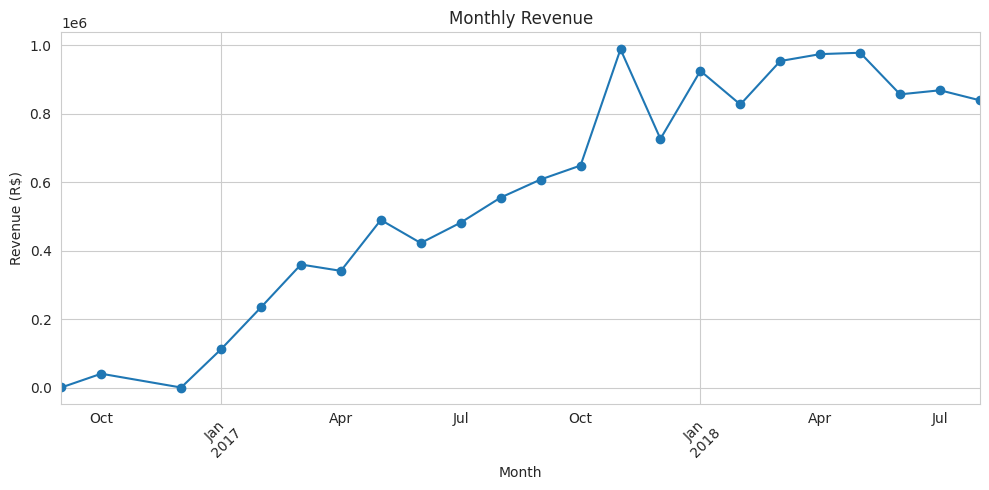

In [6]:
df_delivered["order_month"] = df_delivered["order_purchase_timestamp"].dt.to_period("M")
monthly_revenue = df_delivered.groupby("order_month")["price"].sum()

monthly_revenue.plot(kind="line", marker="o", title="Monthly Revenue")
plt.ylabel("Revenue (R$)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Top Product Categories

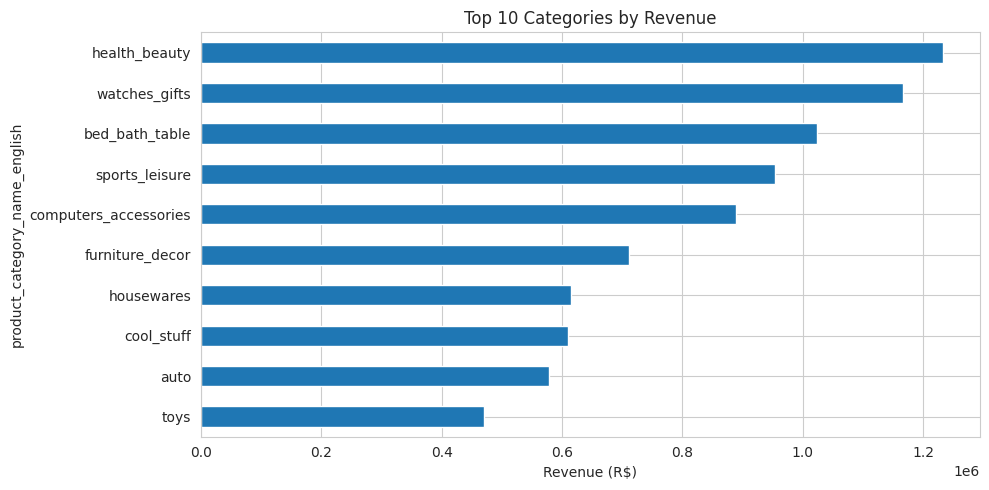

In [7]:
top_categories = (df_delivered.groupby("product_category_name_english")["price"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

top_categories.plot(kind="barh", title="Top 10 Categories by Revenue")
plt.xlabel("Revenue (R$)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Revenue by State

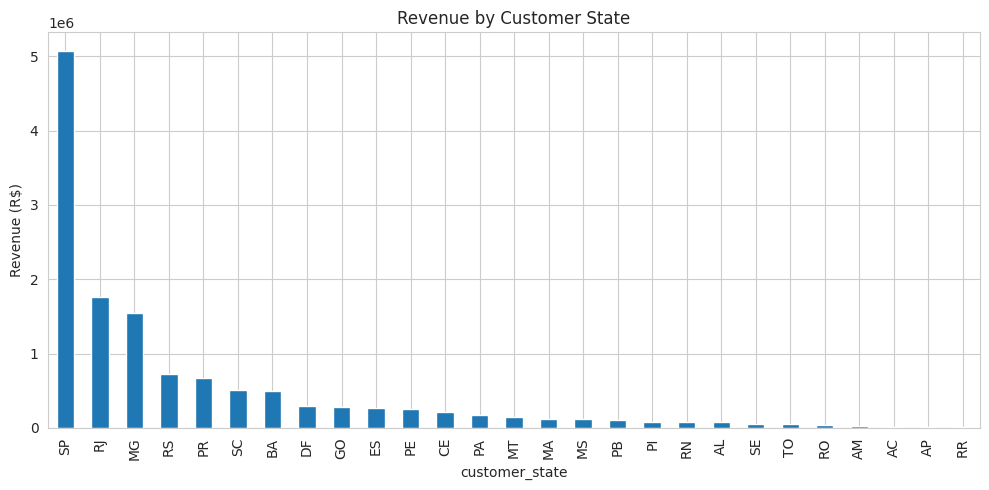

In [8]:
state_revenue = (df_delivered.groupby("customer_state")["price"]
                  .sum()
                  .sort_values(ascending=False))

state_revenue.plot(kind="bar", title="Revenue by Customer State")
plt.ylabel("Revenue (R$)")
plt.tight_layout()
plt.show()

## 7. Average Order Value & Payment Types

Average Order Value: R$ 137.04


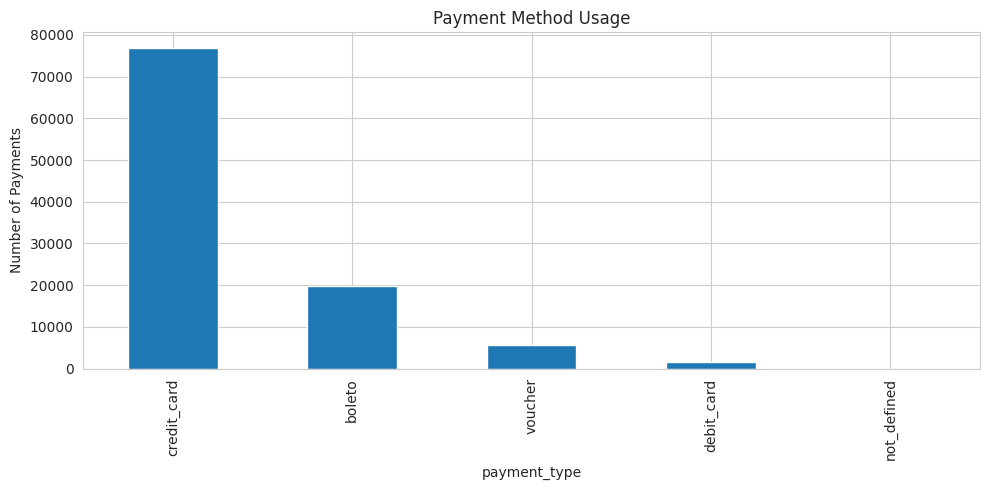

In [9]:
order_value = df_delivered.groupby("order_id")["price"].sum()
print(f"Average Order Value: R$ {order_value.mean():.2f}")

payment_type_counts = payments["payment_type"].value_counts()
payment_type_counts.plot(kind="bar", title="Payment Method Usage")
plt.ylabel("Number of Payments")
plt.tight_layout()
plt.show()

## 8. Delivery Performance vs Review Score
Does late delivery hurt customer satisfaction?

late_delivery
False    4.211551
True     2.548891
Name: review_score, dtype: float64


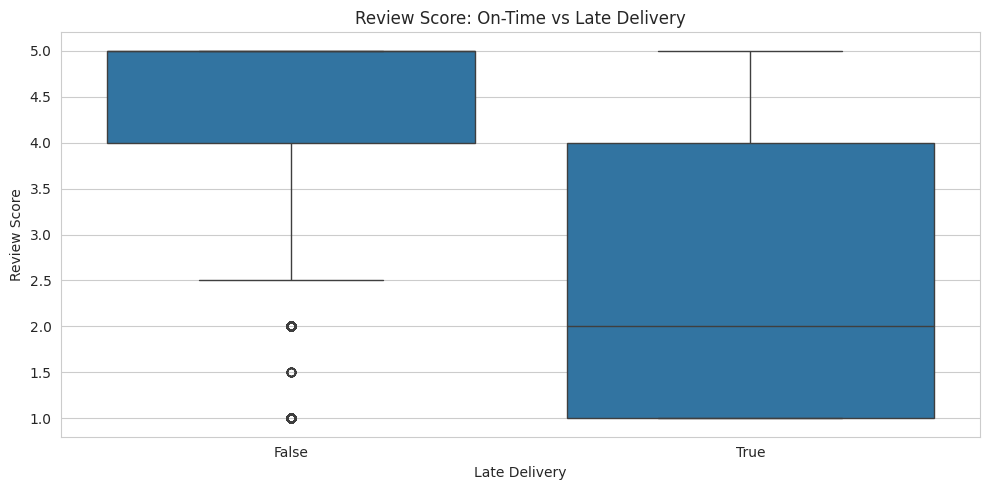

In [10]:
review_by_delivery = df_delivered.groupby("late_delivery")["review_score"].mean()
print(review_by_delivery)

sns.boxplot(data=df_delivered, x="late_delivery", y="review_score")
plt.title("Review Score: On-Time vs Late Delivery")
plt.xlabel("Late Delivery")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

## 9. Key Business Insights

- **Revenue trend:** Total revenue reached R$13.2M across ~110k delivered orders (Sep 2016 - Aug 2018). Revenue grew steadily through 2017, peaking at R$987.8k in November 2017 - likely tied to Black Friday - and has since stabilized around R$850k-975k/month.

- **Top category:** No single category dominates - health_beauty leads at just 9.3% of revenue, followed by watches_gifts (8.8%) and bed_bath_table (7.7%). This suggests a diversified catalog rather than reliance on one hero category, which is lower-risk but also means no single lever to pull for a quick revenue boost.

- **Regional concentration:** Sao Paulo (SP) alone accounts for 38.3% of total revenue - more than double the next state, Rio de Janeiro (13.3%). This heavy geographic concentration is a risk: growth is highly dependent on one region, and underpenetrated states (e.g. GO, ES, DF each under 2.5%) represent expansion opportunity.

- **Delivery drives satisfaction:** This is the standout finding. Orders delivered on time average a 4.21/5 review score, while late orders average just 2.55/5 - a 1.66-point gap. Only 7.9% of orders are late, but each one carries an outsized hit to customer satisfaction.

- **Recommendation:** Prioritize delivery-time reliability (even a small reduction in the 7.9% late-delivery rate would meaningfully lift average review scores) and consider a targeted regional expansion campaign outside SP/RJ/MG, which together already account for over 63% of revenue.



## 10. Export cleaned data for your BI dashboard (Power BI / Tableau)

In [11]:
df_delivered.to_csv("olist_cleaned_for_dashboard.csv", index=False)
print("Saved: olist_cleaned_for_dashboard.csv")
print(f"Rows: {len(df_delivered)}, Columns: {len(df_delivered.columns)}")

Saved: olist_cleaned_for_dashboard.csv
Rows: 110197, Columns: 34
